In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "final" / "conflict_country_year_base.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully.
Shape: (6737, 22)


,country_id,country,year,region,main_government_name,state_based_conflict_exists,state_based_dyad_count,state_based_deaths_best,intrastate_conflict_exists,intrastate_deaths_best,...,non_state_conflict_exists,non_state_dyad_count,non_state_deaths_best,one_sided_violence_exists,one_sided_dyad_count,one_sided_deaths_best,cumulative_organized_violence_deaths_best,ucdp_version,organized_violence_exists,target_conflict_next_year
0,2,United States of America,1989,Americas,Government of United States of America,0,0,0,0,0,...,0,0,0,0,0,0,0,25.1,0,0
1,2,United States of America,1990,Americas,Government of United States of America,0,0,0,0,0,...,0,0,0,0,0,0,0,25.1,0,0
2,2,United States of America,1991,Americas,Government of United States of America,0,0,0,0,0,...,0,0,0,0,0,0,0,25.1,0,0
3,2,United States of America,1992,Americas,Government of United States of America,0,0,0,0,0,...,0,0,0,0,0,0,0,25.1,0,0
4,2,United States of America,1993,Americas,Government of United States of America,0,0,0,0,0,...,0,0,0,0,0,0,0,25.1,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6737 entries, 0 to 6736
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country_id                                 6737 non-null   int64  
 1   country                                    6737 non-null   str    
 2   year                                       6737 non-null   int64  
 3   region                                     6737 non-null   str    
 4   main_government_name                       6737 non-null   str    
 5   state_based_conflict_exists                6737 non-null   int64  
 6   state_based_dyad_count                     6737 non-null   int64  
 7   state_based_deaths_best                    6737 non-null   int64  
 8   intrastate_conflict_exists                 6737 non-null   int64  
 9   intrastate_deaths_best                     6737 non-null   int64  
 10  interstate_conflict_exists         

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
country_id,6737.0,468.014547,263.650706,2.0,290.0,451.0,690.0,990.0
year,6737.0,2006.211667,10.038659,1989.0,1998.0,2006.0,2015.0,2023.0
state_based_conflict_exists,6737.0,0.213448,0.409772,0.0,0.0,0.0,0.0,1.0
state_based_dyad_count,6737.0,0.511207,1.407026,0.0,0.0,0.0,0.0,16.0
state_based_deaths_best,6737.0,333.162981,3666.448559,0.0,0.0,0.0,0.0,163210.0
intrastate_conflict_exists,6737.0,0.209589,0.407045,0.0,0.0,0.0,0.0,1.0
intrastate_deaths_best,6737.0,288.176636,3281.834145,0.0,0.0,0.0,0.0,163210.0
interstate_conflict_exists,6737.0,0.018851,0.136009,0.0,0.0,0.0,0.0,1.0
interstate_deaths_best,6737.0,44.986344,1635.925525,0.0,0.0,0.0,0.0,91435.0
non_state_conflict_exists,6737.0,0.120677,0.325776,0.0,0.0,0.0,0.0,1.0


In [4]:
target_counts = df["target_conflict_next_year"].value_counts().sort_index()
target_percent = df["target_conflict_next_year"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent.round(2)
})

target_summary

,count,percent
target_conflict_next_year,,
0,4750,70.51
1,1987,29.49


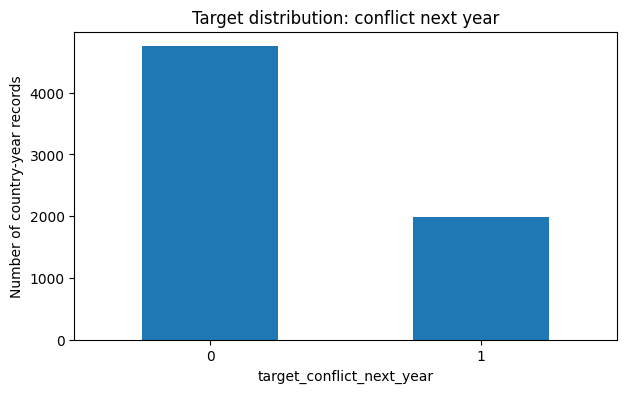

In [5]:
ax = target_counts.plot(kind="bar", figsize=(7, 4))

ax.set_title("Target distribution: conflict next year")
ax.set_xlabel("target_conflict_next_year")
ax.set_ylabel("Number of country-year records")

plt.xticks(rotation=0)
plt.show()

In [6]:
region_counts = df["region"].value_counts()

region_counts

region
Africa         1828
Europe         1646
Asia           1512
Americas       1225
Middle East     526
Name: count, dtype: int64

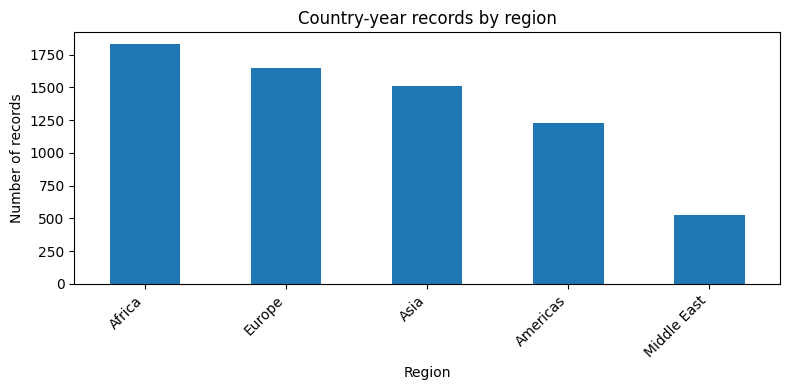

In [7]:
ax = region_counts.plot(kind="bar", figsize=(8, 4))

ax.set_title("Country-year records by region")
ax.set_xlabel("Region")
ax.set_ylabel("Number of records")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
region_target_rate = (
    df.groupby("region")["target_conflict_next_year"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

region_target_rate["mean"] = (region_target_rate["mean"] * 100).round(2)
region_target_rate = region_target_rate.rename(columns={
    "count": "records",
    "sum": "positive_targets",
    "mean": "positive_rate_percent"
})

region_target_rate

,records,positive_targets,positive_rate_percent
region,,,
Middle East,526,260,49.43
Africa,1828,853,46.66
Asia,1512,414,27.38
Americas,1225,278,22.69
Europe,1646,182,11.06


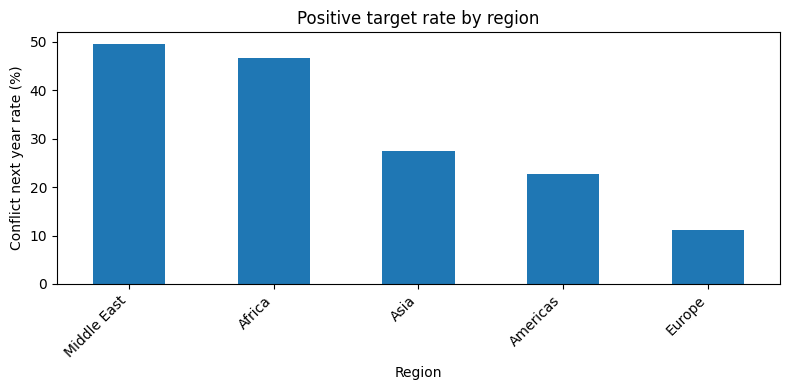

In [9]:
ax = region_target_rate["positive_rate_percent"].plot(kind="bar", figsize=(8, 4))

ax.set_title("Positive target rate by region")
ax.set_xlabel("Region")
ax.set_ylabel("Conflict next year rate (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
year_target_rate = (
    df.groupby("year")["target_conflict_next_year"]
    .agg(["count", "sum", "mean"])
)

year_target_rate["mean"] = (year_target_rate["mean"] * 100).round(2)
year_target_rate = year_target_rate.rename(columns={
    "count": "records",
    "sum": "positive_targets",
    "mean": "positive_rate_percent"
})

year_target_rate.head(), year_target_rate.tail()

(      records  positive_targets  positive_rate_percent
 year                                                  
 1989      172                60                  34.88
 1990      171                55                  32.16
 1991      186                66                  35.48
 1992      188                62                  32.98
 1993      191                61                  31.94,
       records  positive_targets  positive_rate_percent
 year                                                  
 2019      196                63                  32.14
 2020      196                65                  33.16
 2021      196                66                  33.67
 2022      196                64                  32.65
 2023      196                58                  29.59)

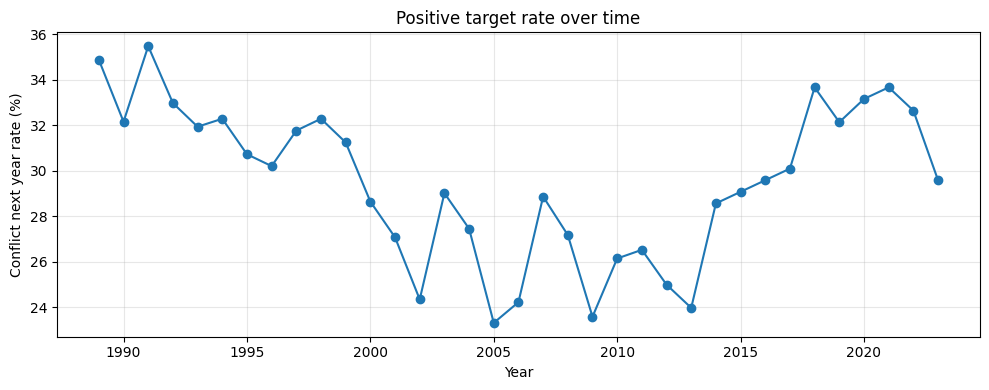

In [11]:
ax = year_target_rate["positive_rate_percent"].plot(figsize=(10, 4), marker="o")

ax.set_title("Positive target rate over time")
ax.set_xlabel("Year")
ax.set_ylabel("Conflict next year rate (%)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
country_positive_counts = (
    df.groupby("country")["target_conflict_next_year"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

country_positive_counts

country
Afghanistan              35
Algeria                  35
Bangladesh               35
DR Congo (Zaire)         35
Ethiopia                 35
Colombia                 35
India                    35
Philippines              35
Nigeria                  35
Somalia                  35
Russia (Soviet Union)    35
Venezuela                35
Turkey                   35
Thailand                 35
Sudan                    35
Name: target_conflict_next_year, dtype: int64

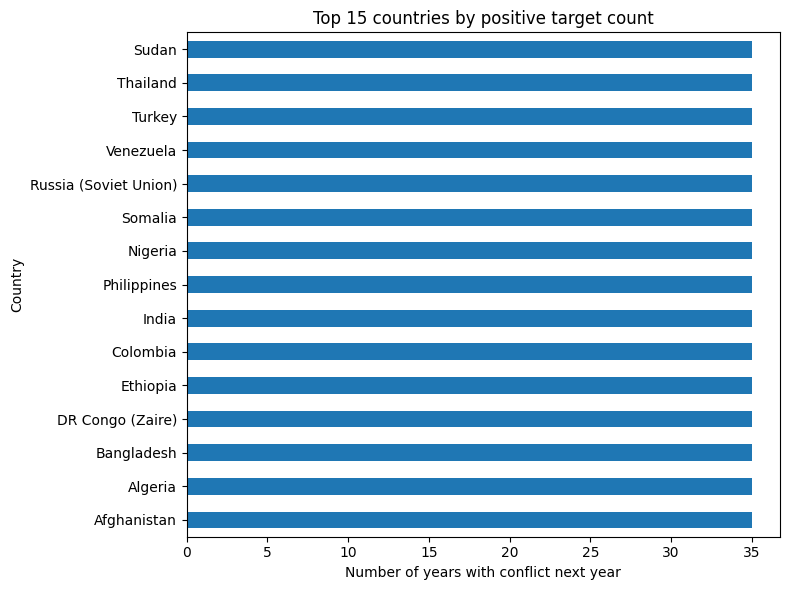

In [13]:
ax = country_positive_counts.sort_values().plot(kind="barh", figsize=(8, 6))

ax.set_title("Top 15 countries by positive target count")
ax.set_xlabel("Number of years with conflict next year")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

In [14]:
persistence_table = pd.crosstab(
    df["organized_violence_exists"],
    df["target_conflict_next_year"],
    normalize="index"
) * 100

persistence_table.round(2)

target_conflict_next_year,0,1
organized_violence_exists,,
0,93.2,6.8
1,16.3,83.7


In [15]:
persistence_counts = pd.crosstab(
    df["organized_violence_exists"],
    df["target_conflict_next_year"]
)

persistence_counts

target_conflict_next_year,0,1
organized_violence_exists,,
0,4426,323
1,324,1664


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_true = df["target_conflict_next_year"]
y_pred_persistence = df["organized_violence_exists"]

baseline_metrics = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score"],
    "value": [
        accuracy_score(y_true, y_pred_persistence),
        precision_score(y_true, y_pred_persistence),
        recall_score(y_true, y_pred_persistence),
        f1_score(y_true, y_pred_persistence),
    ]
})

baseline_metrics["value"] = baseline_metrics["value"].round(4)
baseline_metrics

,metric,value
0,accuracy,0.9040
1,precision,0.8370
2,recall,0.8374
3,f1_score,0.8372


In [18]:
confusion = confusion_matrix(y_true, y_pred_persistence)

confusion_df = pd.DataFrame(
    confusion,
    index=["actual_0", "actual_1"],
    columns=["predicted_0", "predicted_1"]
)

confusion_df

,predicted_0,predicted_1
actual_0,4426,324
actual_1,323,1664
